# 와인등급분류 신경망 구성하기

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1774577635.316035    2314 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774577635.670932    2314 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774577638.968338    2314 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
redwine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep= ';')
redwine.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
X, y = redwine.iloc[:,:-1], redwine.iloc[:,-1]

In [5]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [6]:
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [7]:
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [8]:
y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

# y의 라벨인코딩 3~8 -> 0~5

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
np.unique(y_encoded)

array([0, 1, 2, 3, 4, 5])

# 학습/테스트 데이터 분할 

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [12]:
X_train.shape, X_test.shape

((1279, 11), (320, 11))

In [13]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [14]:
X_train_scaled_ary = np.array(X_train_scaled)
X_test_scaled_ary = np.array(X_test_scaled)

In [15]:
type(X_train_scaled)

numpy.ndarray

# 모델 생성

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model = Sequential()

model.add(Input(shape=(11,))) #입력층

#Hidden 1를 쌓으려고 add Dense라는 객체를 생성
model.add(Dense(100, activation='sigmoid'))
model.add(Dropout(0.2)) #드롭아웃 20%

#Hidden 2
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.4))

#Hidden 3
model.add(Dense(50, activation='tanh'))
model.add(Dropout(0.1))

model.add(Dense(6, activation= 'softmax'))

I0000 00:00:1774577679.743624    2314 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [17]:
from tensorflow.keras.optimizers import Adam
model.compile(
  #optimizer='adam',
  optimizer=Adam(learning_rate=0.001),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,756 (124.05 KB)

 Trainable params: 31,756 (124.05 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(X_train_scaled_ary, y_train, epochs=300, 
                    batch_size=200, validation_split = 0.2,
                    verbose=1)

Epoch 1/300
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6700 - loss: 0.8116

I0000 00:00:1774578443.710374    9150 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1782__.17
I0000 00:00:1774578444.114087    9150 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.6580 - loss: 0.8145

I0000 00:00:1774578448.297191    9151 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6442 - loss: 0.8285 - val_accuracy: 0.6016 - val_loss: 0.9271
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6344 - loss: 0.8335 - val_accuracy: 0.6016 - val_loss: 0.9302
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6403 - loss: 0.8461 - val_accuracy: 0.6016 - val_loss: 0.9359
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6442 - loss: 0.8363 - val_accuracy: 0.5898 - val_loss: 0.9491
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6354 - loss: 0.8442 - val_accuracy: 0.5898 - val_loss: 0.9675
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6354 - loss: 0.8419 - val_accuracy: 0.5977 - val_loss: 0.9515
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6266 - loss: 0.8274 - val_accuracy: 0.6055 - val_loss: 0.9514
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6364 - loss: 0.8290 - val_accuracy: 0.6016 - val_loss: 0.9610
Epoch 

In [25]:
loss, acc = model.evaluate(X_test_scaled_ary, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 0.9830 


In [26]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

이 모델의 학습곡선을 시각화 해주세요.

맷플롯립으로 작성합니다.

In [27]:
def plot_learning_curves(history):
    # 그래프 크기 설정 및 서브플롯 생성
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Loss (손실) 시각화
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    if 'val_loss' in history.history:
        ax[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
    ax[0].set_title('Model Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)

    # 2. Accuracy (정확도) 시각화
    ax[1].plot(history.history['accuracy'], label='Train Accuracy', color='green')
    if 'val_accuracy' in history.history:
        ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
    ax[1].set_title('Model Accuracy')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

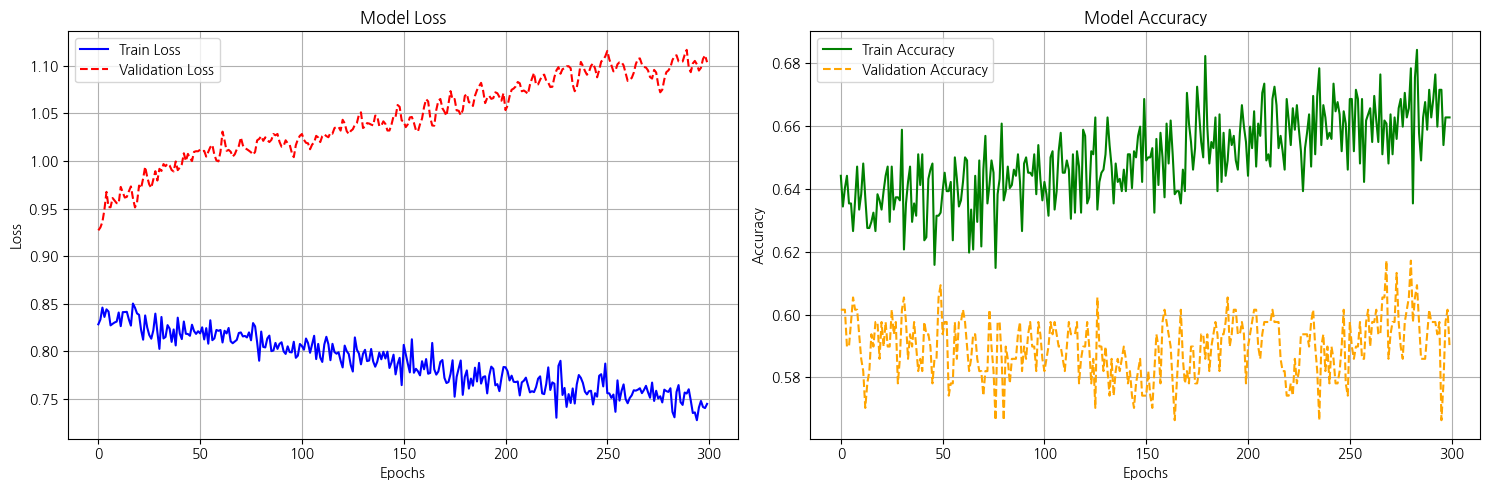

In [28]:
# 함수 실행(사용자님의 변수명 summary를 인자로 전달)
plot_learning_curves(history)

# 조기종료의 적용

In [37]:
# 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model_es = Sequential()
model_es.add(Input(shape=(11,))) #입력층
model_es.add(Dense(100, activation='sigmoid')) #은닉층1
model_es.add(Dropout(0.2))
model_es.add(Dense(200, activation='relu')) #은닉층2
model_es.add(Dropout(0.4))
model_es.add(Dense(50, activation='tanh')) #은닉층3
model_es.add(Dropout(0.1))
model_es.add(Dense(6, activation='softmax')) #출력층

In [38]:
from tensorflow.keras.optimizers import Adam
model_es.compile(
    #optimizer='adam',
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 조기종료의 적용

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
#model.fit(..., callbacks=[early_stop])

history1 = model_es.fit(X_train_scaled_ary, y_train, epochs=300,
                    batch_size=200, 
                    validation_split = 0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/300


I0000 00:00:1774579210.010283    9149 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39347__.17


1/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.0700 - loss: 2.0973

I0000 00:00:1774579211.733112    9149 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39347__.17


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 486ms/step - accuracy: 0.2620 - loss: 1.6659 - val_accuracy: 0.3867 - val_loss: 1.2914
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4555 - loss: 1.2339 - val_accuracy: 0.4102 - val_loss: 1.3270
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4233 - loss: 1.2648 - val_accuracy: 0.4883 - val_loss: 1.2873
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4516 - loss: 1.2014 - val_accuracy: 0.4336 - val_loss: 1.2653
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4418 - loss: 1.1950 - val_accuracy: 0.4883 - val_loss: 1.2351
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4770 - loss: 1.1807 - val_accuracy: 0.5078 - val_loss: 1.2238
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4809 - loss: 1.1605 - val_accuracy: 0.5273 - val_loss: 1.2092
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5015 - loss: 1.1499 - val_accuracy: 0.5312 - val_loss: 1.1875
Epo

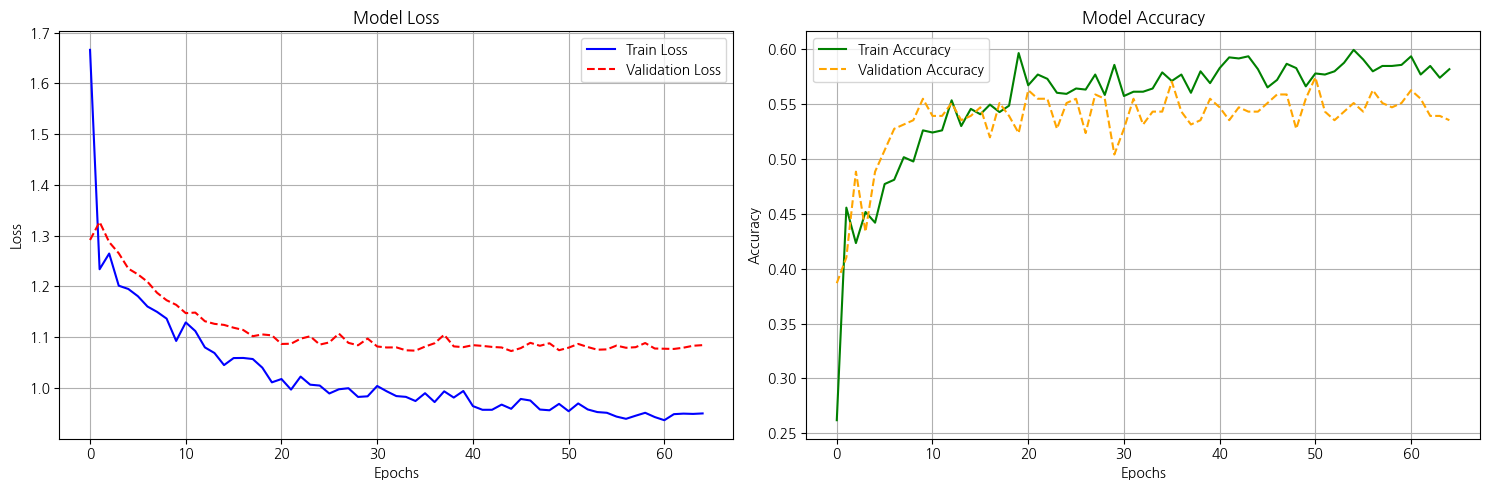

In [40]:
plot_learning_curves(history1)

# 활성화함수의 실행

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

def model_build(act1='sigmoid', act2='relu', act3='tanh'):
    """
    각 은닉층의 활성화 함수를 인자로 받아 모델을 생성하는 함수
    """
    model = Sequential()

    # 입력층 (11개의 피처)
    model.add(Input(shape=(11,))) 

    # 은닉층 1: 100 뉴런
    model.add(Dense(100, activation=act1)) 
    model.add(Dropout(0.2))

    # 은닉층 2: 200 뉴런
    model.add(Dense(200, activation=act2)) 
    model.add(Dropout(0.4))

    # 은닉층 3: 50 뉴런
    model.add(Dense(50, activation=act3)) 
    model.add(Dropout(0.1))

    # 출력층: 6개 클래스 분류 (Softmax 고정)
    model.add(Dense(6, activation='softmax')) 

    return model

# --- 실험 예시 ---
# 모든 층에 ReLU 사용
# model_relu = model_build(act1='relu', act2='relu', act3='relu')

# 기존 설정대로 혼합 사용
# model_mixed = model_build(act1='sigmoid', act2='relu', act3='tanh')

# 모델 구조 확인
# model_mixed.summary()

In [42]:
# 활성화 함수를 relu로 변경하여 모델 생성
model_relu = model_build(act1='relu', act2='relu', act3='relu')

model_relu.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_relu.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,756 (124.05 KB)

 Trainable params: 31,756 (124.05 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history_relu = model_relu.fit(X_train_scaled_ary, y_train, 
                               epochs=300, batch_size=200,
                               validation_split=0.2,
                               verbose=1)

Epoch 1/300


I0000 00:00:1774579877.490127    9149 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45641__.17


1/6 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.2300 - loss: 1.8664

I0000 00:00:1774579879.333154    9150 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45641__.17


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.2795 - loss: 1.7679

I0000 00:00:1774579881.838974    9150 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 737ms/step - accuracy: 0.3099 - loss: 1.7036 - val_accuracy: 0.4805 - val_loss: 1.4850
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4780 - loss: 1.3971 - val_accuracy: 0.5312 - val_loss: 1.3160
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4976 - loss: 1.2513 - val_accuracy: 0.5273 - val_loss: 1.2326
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5513 - loss: 1.1532 - val_accuracy: 0.5352 - val_loss: 1.1952
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5464 - loss: 1.1157 - val_accuracy: 0.5703 - val_loss: 1.1667
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5699 - loss: 1.0845 - val_accuracy: 0.5742 - val_loss: 1.1465
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5894 - loss: 1.0601 - val_accuracy: 0.5586 - val_loss: 1.1385
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5767 - loss: 1.0351 - val_accuracy: 0.5508 - val_loss: 1.1341
Epo

In [45]:
loss, acc = model_relu.evaluate(X_test_scaled_ary, y_test)
print(f'Relu 모델 Test Accuracy: {acc:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6625 - loss: 1.1310 
Relu 모델 Test Accuracy: 0.6625


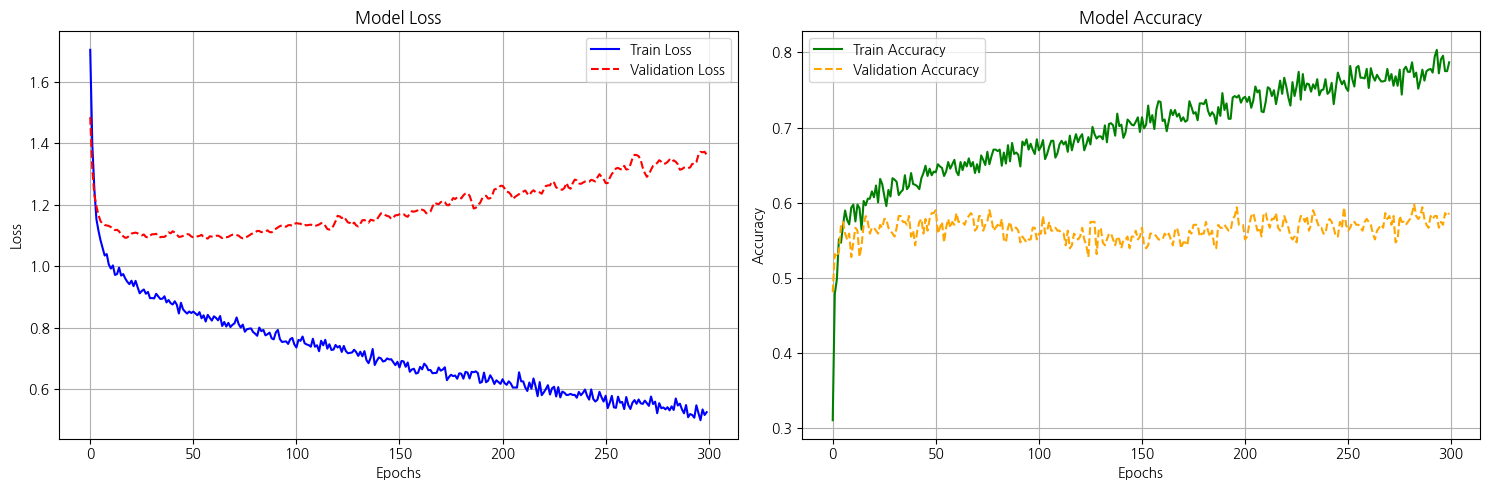

In [46]:
plot_learning_curves(history_relu)

# 배치 정규화의 적용

In [72]:
# 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

model_br = Sequential()
model_br.add(Input(shape=(11,))) #입력층

model_br.add(Dense(100, activation='relu')) #은닉층1
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.2))

model_br.add(Dense(200, activation='relu')) #은닉층2
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.4))

model_br.add(Dense(50, activation='relu')) #은닉층3
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.1))

model_br.add(Dense(6, activation='softmax')) #출력층

from tensorflow.keras.optimizers import Adam
model_br.compile(
    #optimizer='adam',
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [73]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
#model.fit(..., callbacks=[early_stop])

history3 = model_br.fit(X_train_scaled_ary, y_train, epochs=300,
                    batch_size=200, 
                    validation_split = 0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/300


I0000 00:00:1774590238.200890    9151 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_153257__.35


1/6 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.1750 - loss: 2.4331

I0000 00:00:1774590240.683982    9152 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_153257__.35


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 686ms/step - accuracy: 0.2209 - loss: 2.2533 - val_accuracy: 0.2383 - val_loss: 1.7951
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3353 - loss: 1.9184 - val_accuracy: 0.3555 - val_loss: 1.7421
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4154 - loss: 1.7470 - val_accuracy: 0.4336 - val_loss: 1.6923
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4506 - loss: 1.6486 - val_accuracy: 0.4805 - val_loss: 1.6494
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4848 - loss: 1.5617 - val_accuracy: 0.5000 - val_loss: 1.6094
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5171 - loss: 1.4567 - val_accuracy: 0.5234 - val_loss: 1.5698
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5396 - loss: 1.4164 - val_accuracy: 0.5312 - val_loss: 1.5384
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5445 - loss: 1.3876 - val_accuracy: 0.5312 - val_loss: 1.5091
Epo

In [75]:
loss, acc = model_br.evaluate(X_test_scaled_ary, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5938 - loss: 1.0004 


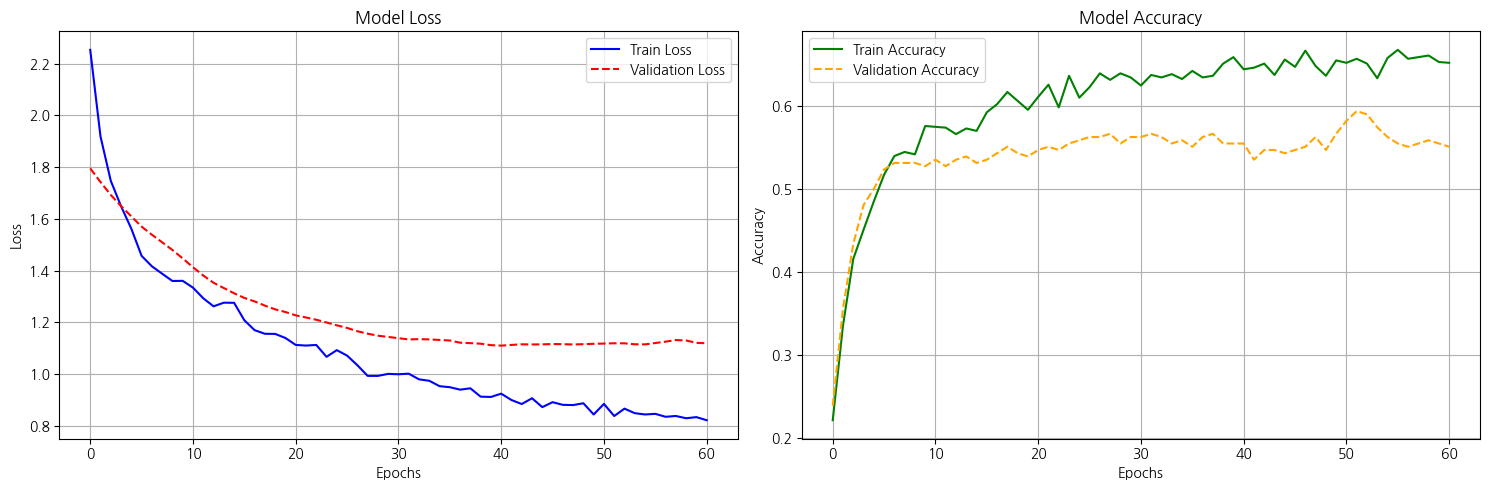

In [76]:
plot_learning_curves(history3)

In [68]:
# 활성화 함수 + 배치 정규화를 함께 적용한 새 모델 구조
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

def model_build_bn(act1='relu', act2='relu', act3='relu'):
    model = Sequential()
    model.add(Input(shape=(11,)))

    # 은닉층 1: 256 뉴런
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation(act1))
    model.add(Dropout(0.2))

    # 은닉층 2: 128 뉴런
    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(Activation(act2))
    model.add(Dropout(0.2))

    # 은닉층 3: 64 뉴런
    model.add(Dense(64))
    model.add(BatchNormalization())
    model.add(Activation(act3))
    model.add(Dropout(0.1))

    # 출력층
    model.add(Dense(6, activation='softmax'))

    return model

model_bn_relu = model_build_bn(act1='relu', act2='relu', act3='relu')

model_bn_relu.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_bn_relu.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,406 (181.27 KB)

 Trainable params: 45,510 (177.77 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/300


I0000 00:00:1774590067.447193    9151 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_144285__.35
I0000 00:00:1774590067.621270    9151 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774590067.934230  172821 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 28 bytes spill stores, 28 bytes spill loads

I0000 00:00:1774590068.022642    9151 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1/6 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step - accuracy: 0.1600 - loss: 2.0935

I0000 00:00:1774590072.468955    9151 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_144285__.35


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.1799 - loss: 2.0368

I0000 00:00:1774590077.115202    9152 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774590078.401970    9151 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774590078.720655  173142 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 16 bytes spill stores, 16 bytes spill loads



6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2063 - loss: 1.9832 - val_accuracy: 0.4219 - val_loss: 1.7027 - learning_rate: 0.0010
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3851 - loss: 1.5826 - val_accuracy: 0.5117 - val_loss: 1.6432 - learning_rate: 0.0010
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4819 - loss: 1.3927 - val_accuracy: 0.5039 - val_loss: 1.5942 - learning_rate: 0.0010
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5484 - loss: 1.2629 - val_accuracy: 0.5117 - val_loss: 1.5524 - learning_rate: 0.0010
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5875 - loss: 1.1732 - val_accuracy: 0.5312 - val_loss: 1.5198 - learning_rate: 0.0010
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5914 - loss: 1.1138 - val_accuracy: 0.5234 - val_loss: 1.4902 - learning_rate: 0.0010
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6051 - loss: 1.0573 - val_accuracy: 0.5469 - val_

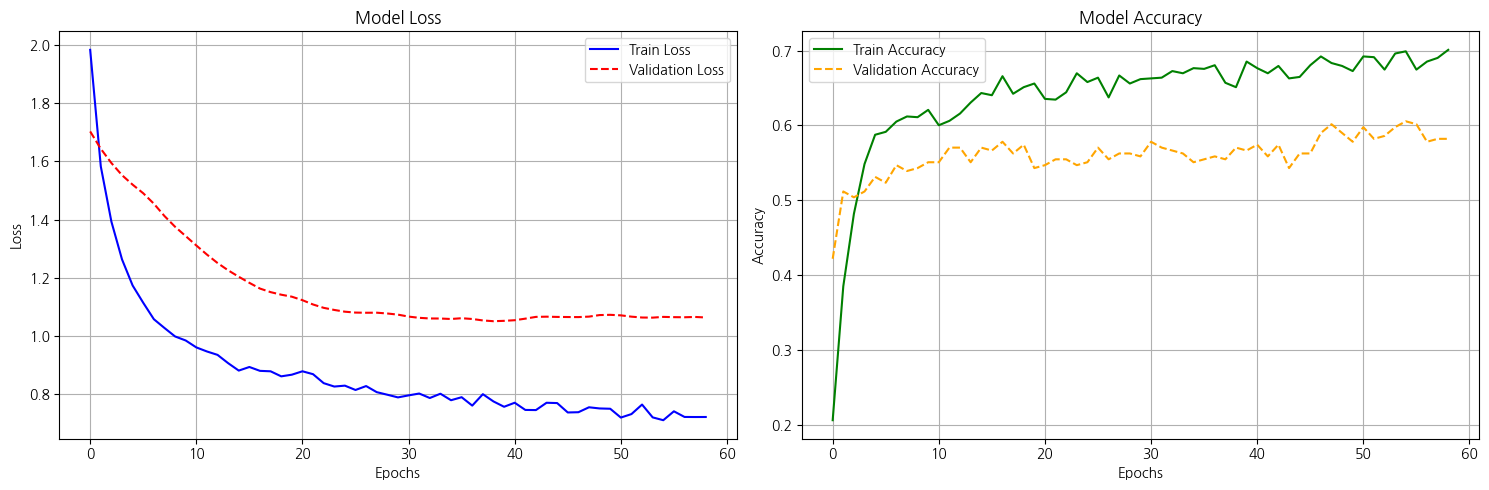

In [70]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)
]

history_bn_relu = model_bn_relu.fit(X_train_scaled_ary, y_train,
                                     epochs=300, batch_size=200,
                                     validation_split=0.2,
                                     callbacks=callbacks2,
                                     verbose=1)

loss, acc = model_bn_relu.evaluate(X_test_scaled_ary, y_test)
print(f'BatchNorm + Relu 모델 Test Accuracy: {acc:.4f}')

plot_learning_curves(history_bn_relu)